In [1]:
#数据预处理
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

sequence_length = 500 # 模型查看的历史窗口大小
prediction_horizon = 1 # 预测的未来窗口大小

directory = "../datas/train" #数据目录
all_items = os.listdir(directory)  #列出目录下所有文件
csv_files = [os.path.join(directory, item) for item in all_items if item.endswith('.csv') and os.path.isfile(os.path.join(directory, item))]  #筛选出CSV文件 
Sample_size = len(csv_files)  #获取样本数量

sequences_data = [] #创建一个空列表，用于存储所有序列的数据
scalers = {} #创建一个空字典，用于存储每个序列对应的标准化器
base_features = ['Voltage', 'Current']
features = ['impedance', 'cumulative_power']

for file in csv_files:
    df = pd.read_csv(file)
    df['impedance'] = df['Voltage'] * 1000 / df['Current'].replace(0, np.nan)
    df['power'] = df['Voltage'] * (df['Current'] / 1000)
    df['cumulative_power'] = (df['power']/1000).cumsum()
    # df['impedance_diff'] = df['impedance'].diff().fillna(0) #添加一阶差分
    # df['impedance_rolling_mean'] = df['impedance'].rolling(window=20, min_periods=1).mean() #滚动均值
    # df['impedance_rolling_std'] = df['impedance'].rolling(window=20, min_periods=1).std()  #滚动标准差
    # df['impedance_slope_10'] = df['impedance'].diff(10) / 10  #过去 10 个时间点的平均变化率。
    # df['impedance_slope_10'] = df['impedance_slope_10'].fillna(0) # 将该列中的所有缺失值（NaN）填充为数字0
    df = df.ffill().bfill()  #缺失值处理先用前向填充，再用后向填充
    #数据预处理 数值归一化
    scaler = StandardScaler() #为当前序列创建一个新的StandardScaler实例
    df.loc[:, features] = scaler.fit_transform(df.loc[:, features]) #对当前序列的指定特征列进行拟合和转换
    scalers[file] = scaler #将当前序列的标准化器保存到字典中，键为序列ID
    sequences_data.append(df[features + ['Action']].values) #将当前序列的数组数据添加到结果列表中

train_sequences, val_sequences = train_test_split(sequences_data, test_size=0.18, random_state=42)

print(f'检索到{Sample_size}个样本')
print(f"特征数量: {len(features)}")
print(f"序列数量: {len(sequences_data)}")
print(f"训练序列: {len(train_sequences)}")
print(f"验证序列: {len(val_sequences)}") 
# print(f"训练样本数: {len(train_dataset)}")
# print(f"验证样本数: {len(val_dataset)}")

检索到55个样本
特征数量: 2
序列数量: 55
训练序列: 45
验证序列: 10


In [2]:
import xgboost as xgb
from tqdm import tqdm

def create_xgboost_data(sequences_data, sequence_length, prediction_horizon):
    X_list = []
    y_list = []
    
    for seq_data in tqdm(sequences_data, desc="处理序列", unit="seq", ncols=60):
        n_samples = len(seq_data) - sequence_length - prediction_horizon + 1
        
        for i in range(n_samples):
            # 提取特征
            x = seq_data[i:i + sequence_length, :-1].flatten()  # 展平为1D向量
            X_list.append(x)
            
            # 提取标签
            y_window = seq_data[i + sequence_length:i + sequence_length + prediction_horizon, -1]
            y = 1 if np.any(y_window == 1) else 0
            y_list.append(y)
    
    return np.array(X_list), np.array(y_list)

print("生成训练数据...")
X_train, y_train = create_xgboost_data(train_sequences, sequence_length, prediction_horizon)
X_val, y_val = create_xgboost_data(val_sequences, sequence_length, prediction_horizon)
# 从float64转化为float32
# X_train = X_train.astype(np.float32)
# y_val = X_val.astype(np.float32)

# 计算类别权重（处理不平衡数据）
# if np.sum(y_train) > 0:
#     scale_pos_weight = (len(y_train) - np.sum(y_train)) / np.sum(y_train)
# else:
#     scale_pos_weight = 1.0
#     print("警告: 训练集中没有正样本!")
scale_pos_weight = 1.0
    
print(f"训练样本数: {len(X_train)}")
print(f"验证样本数: {len(X_val)}")
print(f"训练集形状: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"验证集形状: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"特征维度: {X_train.shape[1]} (序列长度{sequence_length} × 特征数{len(features)})")
print(f"正样本比例 - 训练集: {np.mean(y_train):.4f}, 验证集: {np.mean(y_val):.4f}")
print(f"类别权重 scale_pos_weight: {scale_pos_weight:.2f}")

生成训练数据...


处理序列: 100%|████████████| 10/10 [00:00<00:00, 18.23seq/s]


训练样本数: 530572
验证样本数: 113211
训练集形状: X_train (530572, 1000), y_train (530572,)
验证集形状: X_val (113211, 1000), y_val (113211,)
特征维度: 1000 (序列长度500 × 特征数2)
正样本比例 - 训练集: 0.1427, 验证集: 0.1436
类别权重 scale_pos_weight: 1.00


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib
from sklearn.datasets import dump_svmlight_file
import warnings
warnings.filterwarnings('ignore')

model_name = 'XGBoost'
num_boost_round=1000

# 定义XGBoost模型参数
params = {
    'tree_method': 'hist',  # 使用GPU直方图算法
    'device': 'cuda',           # 指定使用CUDA设备
    'max_bin': 256,                 # 直方图分桶数，GPU上256是常用值，可在速度和精度间权衡
    'objective': 'binary:logistic',  # 根据你的问题调整
    'eval_metric': ['logloss', 'auc', 'error'],
    'learning_rate': 0.1,
    'max_depth': 6,
    'random_state': 42,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'gamma': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'colsample_bylevel': 0.8,   # 每层特征采样
    'colsample_bynode': 0.8,    # 每个节点特征采样
    'scale_pos_weight': scale_pos_weight,
    'verbosity': 1,  # 新版本推荐用法
}
print("XGBoost模型配置完成")
print("创建DMatrix...")
dtrain = xgb.QuantileDMatrix(X_train, label=y_train, max_bin=params['max_bin'])
dval = xgb.QuantileDMatrix(X_val, label=y_val, max_bin=params['max_bin'], ref=dtrain) # ref引用dtrain的分位数
print("创建DMatrix完成")

XGBoost模型配置完成
创建DMatrix...
创建DMatrix完成


In [4]:
# 训练模型
from datetime import datetime

print("开始训练...")
eval_history = {}
# 使用原生接口训练
model = xgb.train(
    params, dtrain,
    num_boost_round,
    evals=[(dtrain, 'train'),(dval, 'val')],  # 这里使用 evals
    early_stopping_rounds=50,
    evals_result=eval_history,  # 这里使用 evals_result
    verbose_eval=True
)
print("XGBoost模型训练完成")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"完成时间{timestamp}")

开始训练...
[0]	train-logloss:0.35097	train-auc:0.99737	train-error:0.14267	val-logloss:0.35194	val-auc:0.99800	val-error:0.14358
[1]	train-logloss:0.30381	train-auc:0.99852	train-error:0.14267	val-logloss:0.30517	val-auc:0.99875	val-error:0.14358
[2]	train-logloss:0.26729	train-auc:0.99893	train-error:0.14267	val-logloss:0.26861	val-auc:0.99882	val-error:0.14358
[3]	train-logloss:0.23764	train-auc:0.99905	train-error:0.14238	val-logloss:0.23920	val-auc:0.99901	val-error:0.14358
[4]	train-logloss:0.21306	train-auc:0.99912	train-error:0.03567	val-logloss:0.21417	val-auc:0.99904	val-error:0.03600
[5]	train-logloss:0.19192	train-auc:0.99918	train-error:0.02617	val-logloss:0.19307	val-auc:0.99905	val-error:0.02300
[6]	train-logloss:0.17361	train-auc:0.99923	train-error:0.01970	val-logloss:0.17497	val-auc:0.99906	val-error:0.01808
[7]	train-logloss:0.15738	train-auc:0.99934	train-error:0.01751	val-logloss:0.15906	val-auc:0.99910	val-error:0.01607
[8]	train-logloss:0.14332	train-auc:0.99938	trai

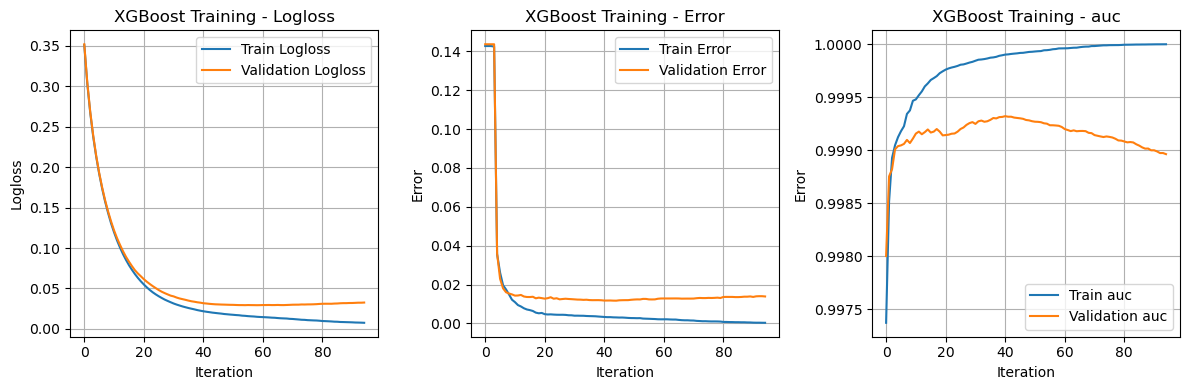

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
# 绘制logloss
plt.subplot(1, 3, 1)
plt.plot(eval_history['train']['logloss'], label='Train Logloss')
plt.plot(eval_history['val']['logloss'], label='Validation Logloss')
plt.xlabel('Iteration')
plt.ylabel('Logloss')
plt.title('XGBoost Training - Logloss')
plt.legend()
plt.grid(True)

# 绘制错误率
plt.subplot(1, 3, 2)
plt.plot(eval_history['train']['error'], label='Train Error')
plt.plot(eval_history['val']['error'], label='Validation Error')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('XGBoost Training - Error')
plt.legend()
plt.grid(True)

# 绘制错误率
plt.subplot(1, 3, 3)
plt.plot(eval_history['train']['auc'], label='Train auc')
plt.plot(eval_history['val']['auc'], label='Validation auc')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('XGBoost Training - auc')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
"""
评估XGBoost模型性能
"""
print("\n" + "="*60)
print("XGBoost模型评估结果")
print("="*60)

# 训练集预测
y_train_prob = model.predict(dtrain)  # 预测概率
y_train_pred = (y_train_prob > 0.5).astype(int)  # 转换为类别

# 验证集预测
y_val_prob = model.predict(dval)  # 预测概率
y_val_pred = (y_val_prob > 0.5).astype(int)  # 转换为类别

# 计算训练集指标
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
train_auc = roc_auc_score(y_train, y_train_prob)

# 计算验证集指标
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
val_auc = roc_auc_score(y_val, y_val_prob)

# 打印结果表格
print(f"{'指标':<12} | {'训练集':<10} | {'验证集':<10}")
print("-" * 40)
print(f"{'准确率':<12} | {train_accuracy:>10.4f} | {val_accuracy:>10.4f}")
print(f"{'精确率':<12} | {train_precision:>10.4f} | {val_precision:>10.4f}")
print(f"{'召回率':<12} | {train_recall:>10.4f} | {val_recall:>10.4f}")
print(f"{'F1分数':<13} | {train_f1:>10.4f} | {val_f1:>10.4f}")
print(f"{'AUC':<14} | {train_auc:>10.4f} | {val_auc:>10.4f}")

# 验证集详细报告
print(f"\n验证集详细分类报告:")
print(classification_report(y_val, y_val_pred, target_names=['Class 0', 'Class 1']))

# 混淆矩阵
cm = confusion_matrix(y_val, y_val_pred)
print(f"\n验证集混淆矩阵:")
print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]

model_name="Model_XGBoost.pkl"

"""
保存XGBoost模型
"""
# 准备保存的数据
model_data = {
    'model': model,
    'feature_names': feature_names,
    'model_type': 'booster'
}
# 获取特征数量
if X_train is not None:
    num_features = X_train.shape[1]
else:
    num_features = len(feature_names)

# 获取最佳迭代轮数
best_iteration = getattr(model, 'best_iteration', '未知')
best_score = getattr(model, 'best_score', '未知')

model_data.update({
    'num_features': num_features,
    'best_iteration': best_iteration,
    'best_score': best_score
})

# 保存模型
joblib.dump(model_data, model_name)
print(f"\n模型已保存为: {model_name}")
print(f"模型类型: Booster (原生接口)")
print(f"特征数量: {model_data.get('num_features', len(feature_names))}")
print(f"最佳迭代轮数: {best_iteration}")
print(f"最佳验证分数: {best_score}")
print(f"类别: [0, 1] (二分类任务)")
print(f"\n{'='*60}")
print("XGBoost模型训练完成!")
print(f"{'='*60}")


XGBoost模型评估结果
指标           | 训练集        | 验证集       
----------------------------------------
准确率          |     0.9996 |     0.9861
精确率          |     0.9994 |     0.9745
召回率          |     0.9981 |     0.9274
F1分数          |     0.9987 |     0.9504
AUC            |     1.0000 |     0.9990

验证集详细分类报告:
              precision    recall  f1-score   support

     Class 0       0.99      1.00      0.99     96956
     Class 1       0.97      0.93      0.95     16255

    accuracy                           0.99    113211
   macro avg       0.98      0.96      0.97    113211
weighted avg       0.99      0.99      0.99    113211


验证集混淆矩阵:
TN: 96562, FP: 394
FN: 1180, TP: 15075

模型已保存为: Model_XGBoost.pkl
模型类型: Booster (原生接口)
特征数量: 1000
最佳迭代轮数: 44
最佳验证分数: 0.01173030889224545
类别: [0, 1] (二分类任务)

XGBoost模型训练完成!
